**Script: General analysis on the output from mux0001_b5b7 series for regional related variables, focusing on the sensitivity**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 15/01/2026
- Lastest modified: 15/01/2026

**Paths**
- the pyic package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
import sys
import cartopy.feature as cfeature
from matplotlib import cm
import cftime

from funcs_plotting import plot_all_vars_3exps
from funcs_process import regional_area_mean

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Paths: data, exp, grid

In [2]:
# data, grid paths
run_def='mux0001_b5b7'
run_ck3='mux0001_b5b7_c_k-03'
run_ck10='mux0001_b5b7_c_k-10'

gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# data paths
path_data = {}
path_data["def"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_def}/outdata/')
path_data["ck3"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_ck3}/outdata/')
path_data["ck10"] = (f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_ck10}/outdata/')

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# ckdtree paths
fpath_tgrid = {}
fpath_ckdtree = {}
# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

# tgrid files
ds_tg = {}
ds_tg["atm"] = xr.open_dataset(fpath_tgrid['atm'])
ds_tg["oce"] = xr.open_dataset(fpath_tgrid['oce'])

## regional mask

In [3]:
# regional masks
mask_2d = {}
mask_2d["atm"] = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm_2d.nc")
mask_2d["oce"] = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce_2d.nc")
mask_2d["cs"] = xr.open_dataset(f"/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_cs_2d.nc")

# Seasonality

## 10 m wind speed (atm grid)

In [4]:
# read the total precip rate for 3 exps and times the regional mask
sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
sp10_ck3 = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_2d_*")["sp_10m"].isel(height=0)
sp10_ck10 = xr.open_mfdataset(f"{path_data['ck10']}{run_ck10}_atm_2d_*")["sp_10m"].isel(height=0)

# last 20 years of data
yr_start = cftime.DatetimeGregorian(1330, 2, 1)
yr_end   = cftime.DatetimeGregorian(1350, 1, 1)
sp10_def = sp10_def.sel(time=slice(yr_start, yr_end))
sp10_ck3 = sp10_ck3.sel(time=slice(yr_start, yr_end))
sp10_ck10 = sp10_ck10.sel(time=slice(yr_start, yr_end))


/tmp/ipykernel_636910/1998538403.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
/tmp/ipykernel_636910/1998538403.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sp10_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["sp_10m"].isel(height=0)
/tmp/ipykernel_636910/1998538403.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=

In [5]:
# monthly climatology
sp10_def_clim = sp10_def.groupby("time.month").mean("time")
sp10_ck3_clim = sp10_ck3.groupby("time.month").mean("time")
sp10_ck10_clim = sp10_ck10.groupby("time.month").mean("time")

# apply the regional mask and calculate the regional mean
# read the cell_area from tgrid file
cell_area = ds_tg["atm"].cell_area.rename({'cell': 'ncells'})
sp10_def_reg = regional_area_mean(sp10_def_clim, cell_area, mask_2d["atm"]["pc_all"])
sp10_ck3_reg = regional_area_mean(sp10_ck3_clim, cell_area, mask_2d["atm"]["pc_all"])
sp10_ck10_reg = regional_area_mean(sp10_ck10_clim, cell_area, mask_2d["atm"]["pc_all"])

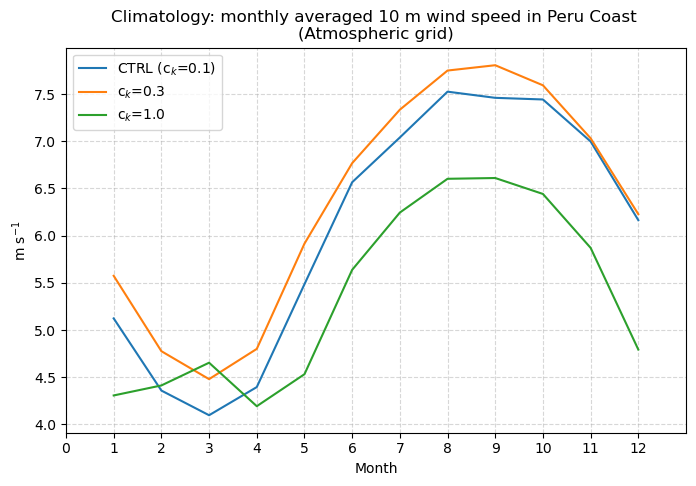

In [73]:
plt.figure(figsize=(8,5))
plt.plot(sp10_def_clim.month, sp10_def_reg, label="CTRL (c$_k$=0.1)")
plt.plot(sp10_ck3_clim.month, sp10_ck3_reg, label="c$_k$=0.3")
plt.plot(sp10_ck10_clim.month, sp10_ck10_reg, label="c$_k$=1.0")
plt.xlabel("Month")
plt.xlim(0,13)
plt.xticks(range(0,13))
plt.ylabel("m s$^{-1}$")
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.title("Climatology: monthly averaged 10 m wind speed in Peru Coast \n(Atmospheric grid)")
save_path = "/home/m/m301254/project_surfwaves/figs/analysis_peru_coast/clim_wind10m_monthly_ave_pc-all.png"
plt.savefig(save_path, dpi=100)
plt.show()

- climatologically, the largest regional averaged local wind speed over focused region happens during **August, September and October**
    - This is the **Winter transitioning into Spring** time in Southern Hemisphere
- the lowest regional averaged wind speed are exhibited during February, March and April, which is the time season transitioning from spring to summer

**found that the ["Wind_speed_10m"] saved in oce_upp has no real output (all value = 0.0)**

## MSLP (ASO vs FMA)

In [24]:
# read the MSLP, with raw unit as Pa
pres_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
pres_ck3 = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_2d_*")["pres_msl"]
pres_ck10 = xr.open_mfdataset(f"{path_data['ck10']}{run_ck10}_atm_2d_*")["pres_msl"]

# last 20 years of data
yr_start = cftime.DatetimeGregorian(1330, 2, 1)
yr_end   = cftime.DatetimeGregorian(1350, 1, 1)
pres_def = pres_def.sel(time=slice(yr_start, yr_end))
pres_ck3 = pres_ck3.sel(time=slice(yr_start, yr_end))
pres_ck10 = pres_ck10.sel(time=slice(yr_start, yr_end))

# months
months_ASO = [8,9,10]
months_FMA = [2,3,4]
pres_def_ASO = pres_def.sel(time=pres_def.time.dt.month.isin(months_ASO)).mean("time")*(1/100)
pres_ck3_ASO = pres_ck3.sel(time=pres_ck3.time.dt.month.isin(months_ASO)).mean("time")*(1/100)
pres_ck10_ASO = pres_ck10.sel(time=pres_ck10.time.dt.month.isin(months_ASO)).mean("time")*(1/100)
pres_def_FMA = pres_def.sel(time=pres_def.time.dt.month.isin(months_FMA)).mean("time")*(1/100)
pres_ck3_FMA = pres_ck3.sel(time=pres_ck3.time.dt.month.isin(months_FMA)).mean("time")*(1/100)
pres_ck10_FMA = pres_ck10.sel(time=pres_ck10.time.dt.month.isin(months_FMA)).mean("time")*(1/100)


/tmp/ipykernel_636910/3829749299.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  pres_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
/tmp/ipykernel_636910/3829749299.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  pres_def = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_2d_*")["pres_msl"]
/tmp/ipykernel_636910/3829749299.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  pres_def = xr.ope

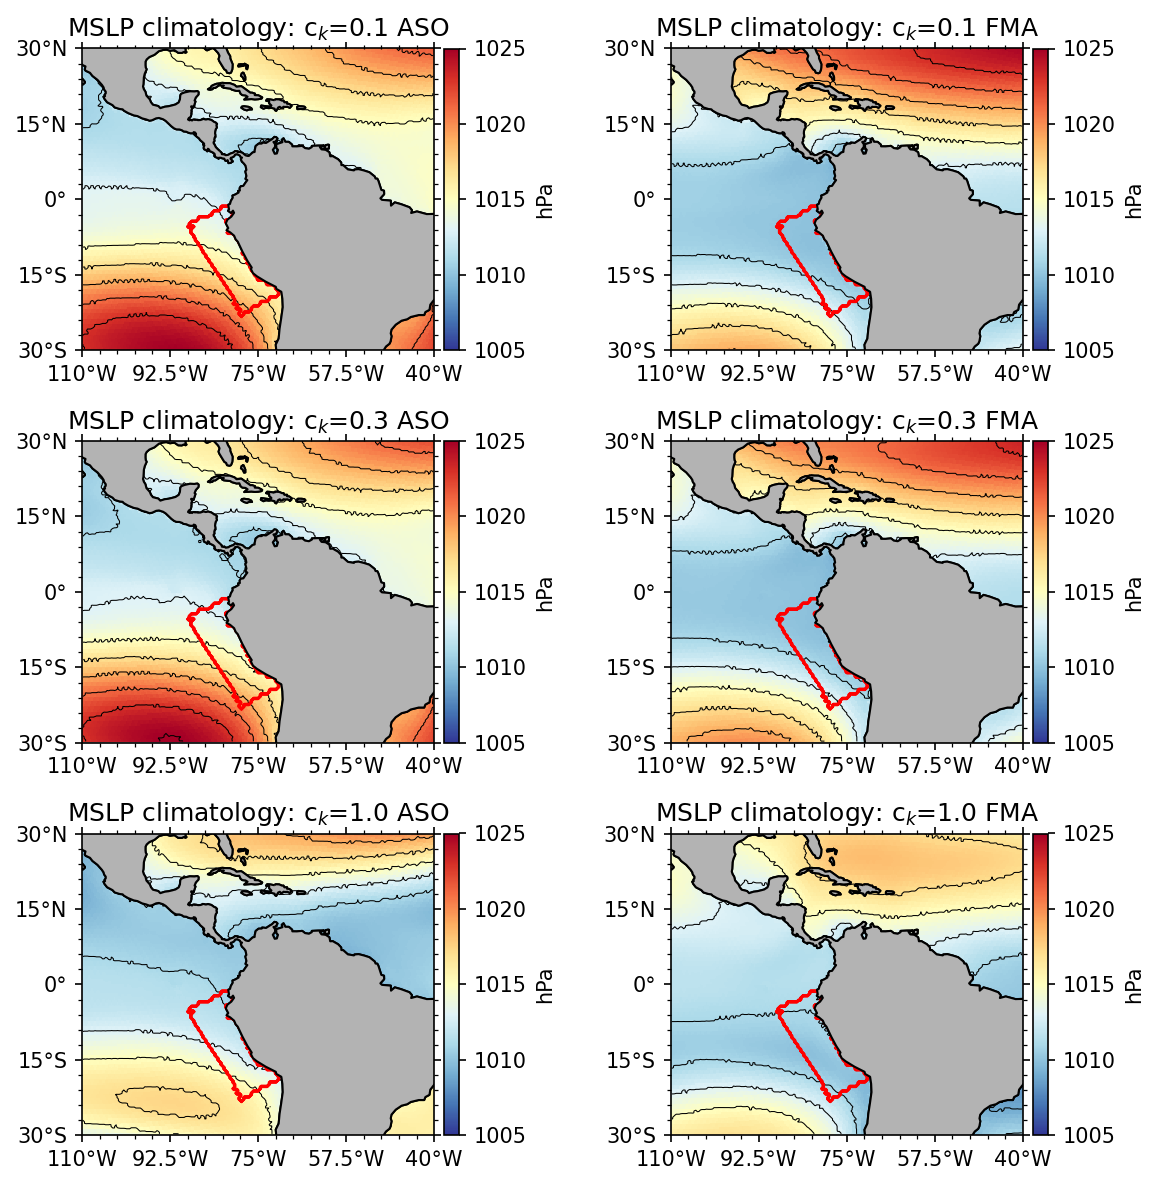

In [74]:
# the figure is set to: (1) ASO clima; (2) FAM Clima; for 3 rolls for diff experiments
# have a look over regional climatological difference 
fig, axes = plt.subplots(3, 2, figsize=(8,8),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            # constrained_layout=True,
                            dpi=150,)
axes = axes.flatten()
fields = [("c$_k$=0.1 ASO", pres_def_ASO, "abs"),
          ("c$_k$=0.1 FMA", pres_def_FMA, "abs"),
        #   ("c$_k$=0.1 ASO-FMA", pres_def_ASO - pres_def_FMA, "anom"),
          ("c$_k$=0.3 ASO", pres_ck3_ASO, "abs"),
          ("c$_k$=0.3 FMA", pres_ck3_FMA, "abs"),
        #   ("c$_k$=0.3 ASO-FMA", pres_ck3_ASO - pres_ck10_FMA, "anom"),
          ("c$_k$=1.0 ASO", pres_ck10_ASO, "abs"),
          ("c$_k$=1.0 FMA", pres_ck10_FMA, "abs"),
        #   ("c$_k$=1,0 ASO-FMA", pres_ck10_ASO - pres_ck10_FMA, "anom"),
          ]
clim_abs = [1005, 1025]   # climatology
clim_anom = [-10, 10]       # ASO − FMA
for ax, (title, field, kind) in zip(axes, fields):
    clim = clim_anom if kind == "anom" else clim_abs
    ax, ct = field.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid["atm"], 
        fpath_ckdtree=fpath_ckdtree["atm"],
        title_right="",
        # land_facecolor="none",
        lon_reg=[-110, -40],
        lat_reg=[-30, 30],
        use_pcol_or_contf=True, 
        # conts=np.arange(1005,1026,4),
        conts="auto",
        # clevs=range(1005, 1026, 1),
        clim=clim,
    )
    fig.colorbar(ct[0], ax=ax, orientation='vertical', label='hPa', pad=0.02)
    for line in ct:
        line.set_linewidths(0.5)
    # plot the masked region
    ax, ct = (mask_2d["atm"]["pc_all"] + 1).pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-110, -40],
        lat_reg=[-30, 30],
        use_pcol_or_contf=False,
        conts=1.0,
        contcolor='red',
    )
    ax.set_title(f"MSLP climatology: {title}")

fig.tight_layout()
save_path = "/home/m/m301254/project_surfwaves/figs/analysis_peru_coast/clim_mslp_ASO_vs_FMA_pc-all.png"
plt.savefig(save_path, dpi=100)
plt.show()

## u, v

In [80]:
yr_start = cftime.DatetimeGregorian(1330, 2, 1)
yr_end   = cftime.DatetimeGregorian(1350, 1, 1)
h_start = 0
h_end = 30
# select specific years and specific heights
sel_kw = dict(
    time=slice(yr_start, yr_end),
    height=slice(h_start, h_end),
)
u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].sel(**sel_kw)
v_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["v"].sel(**sel_kw)
u_ck3  = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_3d_*")["u"].sel(**sel_kw)
v_ck3  = xr.open_mfdataset(f"{path_data['ck3']}{run_ck3}_atm_3d_*")["v"].sel(**sel_kw)
u_ck10 = xr.open_mfdataset(f"{path_data['ck10']}{run_ck10}_atm_3d_*")["u"].sel(**sel_kw)
v_ck10 = xr.open_mfdataset(f"{path_data['ck10']}{run_ck10}_atm_3d_*")["v"].sel(**sel_kw)

/tmp/ipykernel_636910/1133508221.py:10: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].sel(**sel_kw)
/tmp/ipykernel_636910/1133508221.py:10: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  u_def  = xr.open_mfdataset(f"{path_data['def']}{run_def}_atm_3d_*")["u"].sel(**sel_kw)
/tmp/ipykernel_636910/1133508221.py:10: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  u_de

### regional mean Wind speed/direction profile
- first calculate the wind speed for each grid then calculate the regional mean wind speed
- for regional mean wind direction, calculate the regional mean u (i.e., u_bar) and v (i.e., v_bar), then calculate the direcion

In [96]:
# speed 
sp_def = np.sqrt(u_def**2 + v_def**2)
sp_ck3 = np.sqrt(u_ck3**2 + v_ck3**2)
sp_ck10 = np.sqrt(u_ck10**2 + v_ck10**2)

# speed profile
cell_area_atm = ds_tg["atm"].cell_area.rename({'cell': 'ncells'})
mask = mask_2d["atm"]["pc_all"]
sp_prof_def = regional_area_mean(sp_def, cell_area_atm, mask).mean(dim="time")
sp_prof_ck3 = regional_area_mean(sp_ck3, cell_area_atm, mask).mean(dim="time")
sp_prof_ck10 = regional_area_mean(sp_ck10, cell_area_atm, mask).mean(dim="time")

# regional mean u and v at each layer
u_def_bar = regional_area_mean(u_def, cell_area_atm, mask).mean("time")
v_def_bar = regional_area_mean(v_def, cell_area_atm, mask).mean("time")
u_ck3_bar = regional_area_mean(u_ck3, cell_area_atm, mask).mean("time")
v_ck3_bar = regional_area_mean(v_ck3, cell_area_atm, mask).mean("time")
u_ck10_bar = regional_area_mean(u_ck10, cell_area_atm, mask).mean("time")
v_ck10_bar = regional_area_mean(v_ck10, cell_area_atm, mask).mean("time")

# direction profile (mathematical direction)
direc_prof_def = np.arctan2(v_def_bar, u_def_bar) * 180 / np.pi
direc_prof_ck3 = np.arctan2(v_ck3_bar, u_ck3_bar) * 180 / np.pi
direc_prof_ck10 = np.arctan2(v_ck10_bar, u_ck10_bar) * 180 / np.pi

direc_prof_def = (270 - direc_prof_def) % 360
direc_prof_ck3 = (270 - direc_prof_ck3) % 360
direc_prof_ck10 = (270 - direc_prof_ck10) % 360


In [101]:
direc_prof_def.min().compute().item()
direc_prof_def.max().compute().item()

KeyboardInterrupt: 

In [94]:
print(direc_prof_def.min(), direc_prof_def.max())
print(sp_prof_def.min(), sp_prof_def.max())

<xarray.DataArray ()> Size: 8B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray> <xarray.DataArray ()> Size: 8B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
<xarray.DataArray ()> Size: 8B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray> <xarray.DataArray ()> Size: 8B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>


KeyboardInterrupt: 

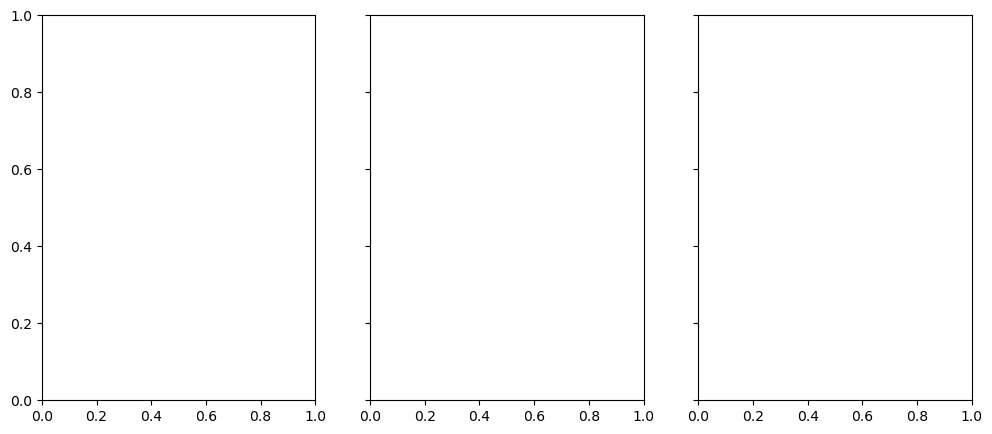

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

profiles = [
    ("c$_k$=0.1", sp_prof_def, direc_prof_def),
    ("c$_k$=0.3", sp_prof_ck3, direc_prof_ck3),
    ("c$_k$=1.0", sp_prof_ck10, direc_prof_ck10),
]

height = sp_prof_def["height"]

for ax, (title, speed, direc) in zip(axes, profiles):

    # speed profile
    ax.plot(speed, height, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Wind speed (m s$^{-1}$)")
    ax.grid(True, alpha=0.3)

    # direction arrows (subsample to avoid clutter)
    skip = 2
    u_arrow = np.cos(np.deg2rad(direc))[::skip]
    v_arrow = np.sin(np.deg2rad(direc))[::skip]

    ax.quiver(
        speed[::skip], height[::skip],
        u_arrow, v_arrow,
        angles="xy", scale_units="xy", scale=8,
        width=0.003,
    )

axes[0].set_ylabel("Height (m)")
plt.tight_layout()
plt.show()

